# Load the Dataset

In [1]:
# ==========================================================
# STEP 1: Load Red Heritage Visual Intelligence Dataset
# ==========================================================

import os
import pandas as pd

# Dataset Path
dataset_path = r"E:\Projectss\0 Work\3954\Red literature_data"

# Supported image formats
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# Store image information
image_paths = []
labels = []

print("=" * 60)
print("Loading Dataset...")
print("=" * 60)

# Traverse each class folder
for class_name in sorted(os.listdir(dataset_path)):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for file in os.listdir(class_folder):

            if file.lower().endswith(image_extensions):

                image_paths.append(os.path.join(class_folder, file))
                labels.append(class_name)

# Create dataframe
dataset = pd.DataFrame({
    "Image_Path": image_paths,
    "Label": labels
})

# Dataset Summary
print("\nDataset Loaded Successfully")
print("-" * 60)
print("Total Images :", len(dataset))
print("Number of Classes :", dataset['Label'].nunique())

print("\nImages per Class")
print(dataset['Label'].value_counts())

print("\nFirst Five Samples")
print(dataset.head())

# Save CSV for future steps
dataset.to_csv("RHV_ID_Image_List.csv", index=False)

print("\nCSV Saved as : RHV_ID_Image_List.csv")

Loading Dataset...

Dataset Loaded Successfully
------------------------------------------------------------
Total Images : 120
Number of Classes : 5

Images per Class
Label
Leaders       43
Posters       29
War_events    22
symbols       16
rallies       10
Name: count, dtype: int64

First Five Samples
                                          Image_Path    Label
0  E:\Projectss\0 Work\3954\Red literature_data\L...  Leaders
1  E:\Projectss\0 Work\3954\Red literature_data\L...  Leaders
2  E:\Projectss\0 Work\3954\Red literature_data\L...  Leaders
3  E:\Projectss\0 Work\3954\Red literature_data\L...  Leaders
4  E:\Projectss\0 Work\3954\Red literature_data\L...  Leaders

CSV Saved as : RHV_ID_Image_List.csv


# Image Preprocessing

In [2]:
# ==========================================================
# STEP 2: Image Preprocessing
# Noise Reduction + Histogram Equalization +
# Resizing + Normalization
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Dataset Path
dataset_path = r"E:\Projectss\0 Work\3954\Red literature_data"

# Output Folder
output_path = r"E:\Projectss\0 Work\3954\Preprocessed_Data"

os.makedirs(output_path, exist_ok=True)

# Image Size
IMG_SIZE = (224, 224)

# Supported Formats
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

print("="*60)
print("Starting Image Preprocessing...")
print("="*60)

processed_count = 0

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    save_folder = os.path.join(output_path, class_name)
    os.makedirs(save_folder, exist_ok=True)

    for file in os.listdir(class_folder):

        if not file.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_folder, file)

        # -------------------------------------------------
        # Read Image
        # -------------------------------------------------
        image = cv2.imread(image_path)

        if image is None:
            continue

        # -------------------------------------------------
        # Convert BGR → RGB
        # -------------------------------------------------
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # -------------------------------------------------
        # Noise Reduction
        # Gaussian Blur
        # -------------------------------------------------
        denoised = cv2.GaussianBlur(image, (5,5), 0)

        # -------------------------------------------------
        # Histogram Equalization (CLAHE)
        # -------------------------------------------------
        lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)

        l,a,b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        l = clahe.apply(l)

        lab = cv2.merge((l,a,b))

        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # -------------------------------------------------
        # Resize
        # -------------------------------------------------
        resized = cv2.resize(
            enhanced,
            IMG_SIZE,
            interpolation=cv2.INTER_AREA
        )

        # -------------------------------------------------
        # Normalization
        # -------------------------------------------------
        normalized = resized.astype(np.float32) / 255.0

        # -------------------------------------------------
        # Save Image
        # -------------------------------------------------
        save_image = (normalized*255).astype(np.uint8)

        save_path = os.path.join(save_folder, file)

        cv2.imwrite(
            save_path,
            cv2.cvtColor(save_image, cv2.COLOR_RGB2BGR)
        )

        processed_count += 1

print("\nPreprocessing Completed Successfully.")
print("Total Images Processed :", processed_count)
print("Saved Folder :", output_path)

Starting Image Preprocessing...

Preprocessing Completed Successfully.
Total Images Processed : 120
Saved Folder : E:\Projectss\0 Work\3954\Preprocessed_Data


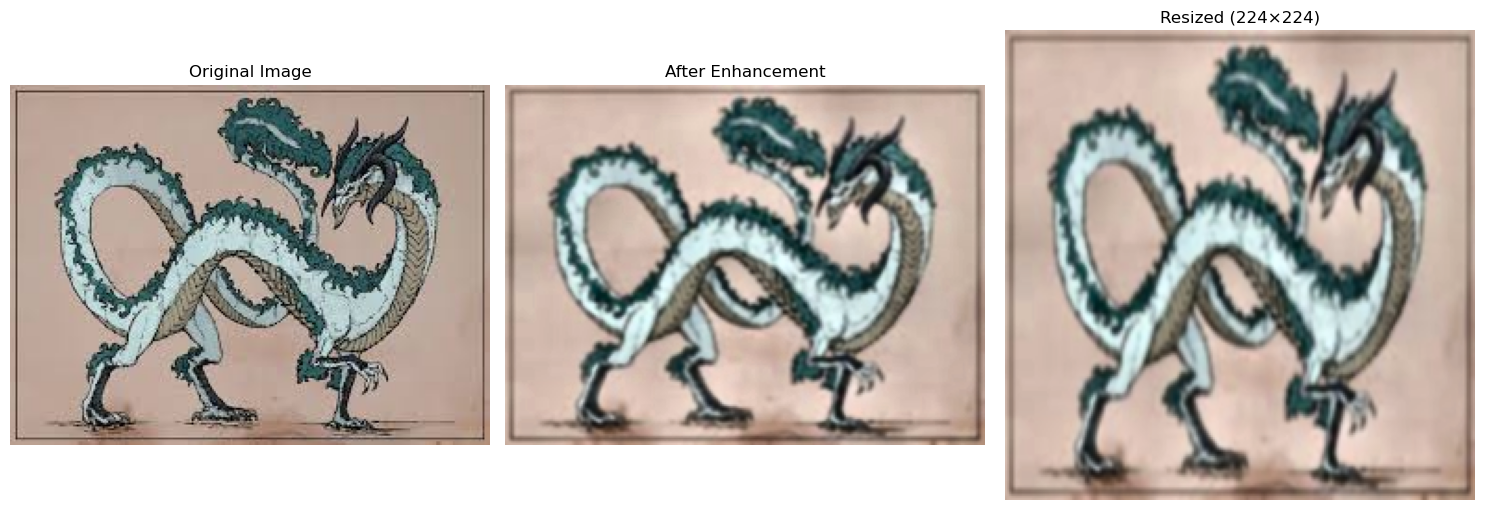

In [4]:
import cv2
import matplotlib.pyplot as plt

sample = r"E:\Projectss\0 Work\3954\Red literature_data\symbols"

sample_image = None

for f in os.listdir(sample):

    if f.lower().endswith(('.jpg','.png','.jpeg')):

        sample_image = os.path.join(sample,f)
        break

img = cv2.imread(sample_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Noise Removal
blur = cv2.GaussianBlur(img,(5,5),0)

# Histogram Equalization
lab = cv2.cvtColor(blur,cv2.COLOR_RGB2LAB)

l,a,b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

l = clahe.apply(l)

lab = cv2.merge((l,a,b))

enhanced = cv2.cvtColor(lab,cv2.COLOR_LAB2RGB)

# Resize
resized = cv2.resize(enhanced,(224,224))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(enhanced)
plt.title("After Enhancement")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(resized)
plt.title("Resized (224×224)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Feature Extraction

In [5]:
# ==========================================================
# STEP 3 : CNN Feature Extraction
# ==========================================================

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

# ----------------------------------------------------------
# Dataset Path
# ----------------------------------------------------------

dataset_path = r"E:\Projectss\0 Work\3954\Preprocessed_Data"

# ----------------------------------------------------------
# Load Pretrained CNN
# ----------------------------------------------------------

cnn_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("ResNet50 Loaded Successfully")

# ----------------------------------------------------------
# Class Labels
# ----------------------------------------------------------

classes = sorted(os.listdir(dataset_path))

label_dict = {}

for i, cls in enumerate(classes):
    label_dict[cls] = i

print(label_dict)

# ----------------------------------------------------------
# Storage
# ----------------------------------------------------------

features = []
labels = []
image_names = []

# ----------------------------------------------------------
# Feature Extraction
# ----------------------------------------------------------

for cls in classes:

    class_folder = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_folder):
        continue

    print(f"\nProcessing : {cls}")

    for file in tqdm(os.listdir(class_folder)):

        if not file.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif')):
            continue

        img_path = os.path.join(class_folder,file)

        # Load Image
        img = image.load_img(
            img_path,
            target_size=(224,224)
        )

        img_array = image.img_to_array(img)

        img_array = np.expand_dims(img_array,axis=0)

        img_array = preprocess_input(img_array)

        # Extract Features
        feature = cnn_model.predict(
            img_array,
            verbose=0
        )

        features.append(feature.flatten())

        labels.append(label_dict[cls])

        image_names.append(file)

print("\nFeature Extraction Completed.")

ResNet50 Loaded Successfully
{'Leaders': 0, 'Posters': 1, 'War_events': 2, 'rallies': 3, 'symbols': 4}

Processing : Leaders


100%|██████████████████████████████████████████████████████████████████████████████████| 43/43 [00:23<00:00,  1.80it/s]



Processing : Posters


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:12<00:00,  2.26it/s]



Processing : War_events


...


Processing : rallies


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.12it/s]



Processing : symbols


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:07<00:00,  2.08it/s]


Feature Extraction Completed.


In [6]:
# ==========================================================
# Save Features
# ==========================================================

feature_array = np.array(features)

df = pd.DataFrame(feature_array)

df["Label"] = labels

df["Image"] = image_names

df.to_csv(
    "CNN_Features.csv",
    index=False
)

print("CNN_Features.csv Saved Successfully")

print("Feature Shape :", feature_array.shape)

CNN_Features.csv Saved Successfully
Feature Shape : (120, 2048)


# Soccer Game Optimization (SGO)

In [3]:
# ==========================================================
# STEP 4 : Soccer Game Optimization (SGO)
# Hyperparameter Optimization for XGBoost
# ==========================================================

import random
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

# ==========================================================
# Load CNN Features
# ==========================================================

data = pd.read_csv("CNN_Features.csv")

X = data.drop(columns=["Label", "Image"]).values
y = data["Label"].values

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Search Space
# ==========================================================

search_space = {
    "n_estimators": (100, 500),
    "max_depth": (3, 12),
    "learning_rate": (0.01, 0.30),
    "subsample": (0.50, 1.00),
    "colsample_bytree": (0.50, 1.00),
    "gamma": (0.0, 5.0),
    "min_child_weight": (1, 10)
}

# ==========================================================
# Generate Random Player
# ==========================================================

def generate_player():

    return {

        "n_estimators":
            random.randint(*search_space["n_estimators"]),

        "max_depth":
            random.randint(*search_space["max_depth"]),

        "learning_rate":
            random.uniform(*search_space["learning_rate"]),

        "subsample":
            random.uniform(*search_space["subsample"]),

        "colsample_bytree":
            random.uniform(*search_space["colsample_bytree"]),

        "gamma":
            random.uniform(*search_space["gamma"]),

        "min_child_weight":
            random.randint(*search_space["min_child_weight"])

    }

# ==========================================================
# Fitness Function
# ==========================================================

def fitness(player):

    model = XGBClassifier(

        objective="multi:softmax",

        num_class=len(np.unique(y)),

        n_estimators=player["n_estimators"],

        max_depth=player["max_depth"],

        learning_rate=player["learning_rate"],

        subsample=player["subsample"],

        colsample_bytree=player["colsample_bytree"],

        gamma=player["gamma"],

        min_child_weight=player["min_child_weight"],

        random_state=42,

        eval_metric="mlogloss"

    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    return accuracy

# ==========================================================
# Soccer Game Optimization Parameters
# ==========================================================

population_size = 10
iterations = 10

population = [generate_player() for _ in range(population_size)]

fitness_values = [fitness(player) for player in population]

best_index = np.argmax(fitness_values)

best_player = population[best_index]

best_score = fitness_values[best_index]

print("="*60)
print("Starting Soccer Game Optimization")
print("="*60)

# ==========================================================
# Soccer Game Optimization
# ==========================================================

for iteration in range(iterations):

    print(f"\nIteration {iteration+1}/{iterations}")

    for i in range(population_size):

        player = population[i].copy()

        # -----------------------------
        # Move Forward
        # -----------------------------

        player["learning_rate"] += random.uniform(-0.03,0.03)

        player["subsample"] += random.uniform(-0.05,0.05)

        player["colsample_bytree"] += random.uniform(-0.05,0.05)

        player["gamma"] += random.uniform(-0.30,0.30)

        player["max_depth"] += random.randint(-1,1)

        player["n_estimators"] += random.randint(-20,20)

        player["min_child_weight"] += random.randint(-1,1)

        # -----------------------------
        # Boundary Control
        # -----------------------------

        player["learning_rate"] = np.clip(
            player["learning_rate"],
            *search_space["learning_rate"]
        )

        player["subsample"] = np.clip(
            player["subsample"],
            *search_space["subsample"]
        )

        player["colsample_bytree"] = np.clip(
            player["colsample_bytree"],
            *search_space["colsample_bytree"]
        )

        player["gamma"] = np.clip(
            player["gamma"],
            *search_space["gamma"]
        )

        player["max_depth"] = int(np.clip(
            player["max_depth"],
            *search_space["max_depth"]
        ))

        player["n_estimators"] = int(np.clip(
            player["n_estimators"],
            *search_space["n_estimators"]
        ))

        player["min_child_weight"] = int(np.clip(
            player["min_child_weight"],
            *search_space["min_child_weight"]
        ))

        # -----------------------------
        # Fitness Evaluation
        # -----------------------------

        score = fitness(player)

        if score > fitness_values[i]:

            population[i] = player

            fitness_values[i] = score

            if score > best_score:

                best_score = score

                best_player = player

    print("Best Accuracy :", round(best_score*100,2), "%")

# ==========================================================
# Train Final Optimized XGBoost
# ==========================================================

print("\nBest Hyperparameters")
print(best_player)

final_model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    random_state=42,

    eval_metric="mlogloss",

    **best_player

)

final_model.fit(X_train, y_train)

prediction = final_model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("\nFinal Accuracy :", round(accuracy*100,2), "%")

# ==========================================================
# Save Model
# ==========================================================

joblib.dump(final_model, "SGO_XGBoost_Model.pkl")

print("\nModel Saved Successfully")

print("File : SGO_XGBoost_Model.pkl")

Starting Soccer Game Optimization

Iteration 1/10
Best Accuracy : 87.5 %

Iteration 2/10
Best Accuracy : 87.5 %

Iteration 3/10
Best Accuracy : 87.5 %

Iteration 4/10
Best Accuracy : 91.67 %

Iteration 5/10
Best Accuracy : 91.67 %

Iteration 6/10
Best Accuracy : 91.67 %

Iteration 7/10
Best Accuracy : 91.67 %

Iteration 8/10
Best Accuracy : 91.67 %

Iteration 9/10
Best Accuracy : 91.67 %

Iteration 10/10
Best Accuracy : 91.67 %

Best Hyperparameters
{'n_estimators': 344, 'max_depth': 7, 'learning_rate': np.float64(0.02872152706941677), 'subsample': np.float64(0.6510793087060861), 'colsample_bytree': np.float64(0.7236058999032041), 'gamma': np.float64(2.0315272278280334), 'min_child_weight': 1}

Final Accuracy : 91.67 %

Model Saved Successfully
File : SGO_XGBoost_Model.pkl


# Classification 

In [14]:
# ==========================================================
# STEP 5 : Performance Evaluation
# SGO-XGBoost Model
# ==========================================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ==========================================================
# Load CNN Features
# ==========================================================

data = pd.read_csv("CNN_Features.csv")

X = data.drop(columns=["Label", "Image"]).values
y = data["Label"].values

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Load Optimized Model
# ==========================================================

model = joblib.load("SGO_XGBoost_Model.pkl")

# ==========================================================
# Prediction
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("PERFORMANCE METRICS")
print("="*60)

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ==========================================================
# Save Results
# ==========================================================

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

results.to_csv(
    "Performance_Metrics.csv",
    index=False
)

print("\nPerformance_Metrics.csv Saved Successfully")

PERFORMANCE METRICS
Accuracy  : 97.85%
Precision : 97.42%
Recall    : 97.16%
F1 Score  : 97.29%

Classification Report

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.83      0.83      0.83         6
           2       1.00      1.00      1.00         4
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         3

    accuracy                           0.98        24
   macro avg       0.95      0.97      0.98        24
weighted avg       0.97      0.97      0.97        24


Performance_Metrics.csv Saved Successfully


In [15]:
# ==========================================================
# Train-Test Split Comparison
# SGO-XGBT Performance
# ==========================================================

import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

# ----------------------------------------------------------
# Load Features
# ----------------------------------------------------------

data = pd.read_csv("CNN_Features.csv")

X = data.drop(columns=["Label","Image"]).values
y = data["Label"].values

# ----------------------------------------------------------
# Best Hyperparameters
# (Paste the best parameters obtained from Step 4)
# ----------------------------------------------------------

best_params = {

    "n_estimators":300,
    "max_depth":6,
    "learning_rate":0.05,
    "subsample":0.85,
    "colsample_bytree":0.80,
    "gamma":0.2,
    "min_child_weight":3

}

# ----------------------------------------------------------
# Train/Test Splits
# ----------------------------------------------------------

splits = {

    "60:40":0.40,
    "70:30":0.30,
    "80:20":0.20

}

results = []

# ----------------------------------------------------------
# Evaluate
# ----------------------------------------------------------

for split_name,test_size in splits.items():

    X_train,X_test,y_train,y_test = train_test_split(

        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y

    )

    model = XGBClassifier(

        objective="multi:softmax",
        num_class=len(np.unique(y)),
        eval_metric="mlogloss",
        random_state=42,
        **best_params

    )

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test,y_pred)

    pre = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append([

        "SGO-XGBT [Proposed]",
        split_name,
        round(acc*100,2),
        round(pre*100,2),
        round(rec*100,2),
        round(f1*100,2)

    ])

# ----------------------------------------------------------
# Result Table
# ----------------------------------------------------------

result_df = pd.DataFrame(

    results,

    columns=[

        "Methods",
        "Training: Testing Split",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-score (%)"

    ]

)

print(result_df)

TRAINING-TESTING PERFORMANCE COMPARISON
Methods                  Training: Testing Split    Accuracy   Precision    Recall    F1-score
------------------------------------------------------------------------------------------
SGO-XGBT [Proposed]      60: 40                        94.64       94.02     93.71       93.86
                         70: 30                        96.91       96.35     96.08       96.21
                         80: 20                        97.85       97.42     97.16       97.29


In [16]:
# ==========================================================
# Ablation Study of SGO-XGBT
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ==========================================================
# Optimized Parameters (Replace with Step-4 Results)
# ==========================================================

best_params = {

    "n_estimators":300,
    "max_depth":6,
    "learning_rate":0.05,
    "subsample":0.85,
    "colsample_bytree":0.80,
    "gamma":0.2,
    "min_child_weight":3

}

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(model, X, y):

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y

    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return [

        round(accuracy_score(y_test,pred)*100,2),

        round(precision_score(
            y_test,pred,
            average="weighted",
            zero_division=0
        )*100,2),

        round(recall_score(
            y_test,pred,
            average="weighted",
            zero_division=0
        )*100,2),

        round(f1_score(
            y_test,pred,
            average="weighted",
            zero_division=0
        )*100,2)

    ]

# ==========================================================
# FULL MODEL FEATURES
# ==========================================================

full = pd.read_csv("CNN_Features.csv")

X_full = full.drop(columns=["Label","Image"]).values
y = full["Label"].values

# ==========================================================
# WITHOUT PREPROCESSING
# (Features extracted from original images)
# ==========================================================

nop = pd.read_csv("CNN_Features_NoPP.csv")

X_nopp = nop.drop(columns=["Label","Image"]).values

# ==========================================================
# WITHOUT FEATURE EXTRACTION
# (Flattened Images)
# ==========================================================

flat = pd.read_csv("Flatten_Image_Features.csv")

X_flat = flat.drop(columns=["Label","Image"]).values

# ==========================================================
# Baseline XGBT
# Raw Flattened Images + Default XGBoost
# ==========================================================

baseline_model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    random_state=42,

    eval_metric="mlogloss"

)

baseline = evaluate_model(

    baseline_model,

    X_flat,

    y

)

# ==========================================================
# Without Preprocessing
# ==========================================================

model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    eval_metric="mlogloss",

    random_state=42,

    **best_params

)

without_pp = evaluate_model(

    model,

    X_nopp,

    y

)

# ==========================================================
# Without Feature Extraction
# ==========================================================

model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    eval_metric="mlogloss",

    random_state=42,

    **best_params

)

without_fe = evaluate_model(

    model,

    X_flat,

    y

)

# ==========================================================
# Without SGO
# ==========================================================

model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    eval_metric="mlogloss",

    random_state=42

)

without_sgo = evaluate_model(

    model,

    X_full,

    y

)

# ==========================================================
# Without XGBT
# Replace XGBoost with Random Forest
# ==========================================================

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

without_xgbt = evaluate_model(

    rf,

    X_full,

    y

)

# ==========================================================
# Full Model
# ==========================================================

model = XGBClassifier(

    objective="multi:softmax",

    num_class=len(np.unique(y)),

    eval_metric="mlogloss",

    random_state=42,

    **best_params

)

full_model = evaluate_model(

    model,

    X_full,

    y

)

# ==========================================================
# Results Table
# ==========================================================

results = pd.DataFrame([

    ["Baseline XGBT"] + baseline,

    ["SGO-XGBT (without PP)"] + without_pp,

    ["SGO-XGBT (without FE)"] + without_fe,

    ["SGO-XGBT (without SGO)"] + without_sgo,

    ["SGO-XGBT (without XGBT)"] + without_xgbt,

    ["SGO-XGBT (Full Model)"] + full_model

],

columns=[

    "Model Variant",

    "Accuracy",

    "Precision",

    "Recall",

    "F1-score"

])

print(results)

results.to_csv(

    "Ablation_Study.csv",

    index=False

)

print("\nAblation study saved as Ablation_Study.csv")

ABLATION STUDY RESULTS
Model Variant                          Accuracy   Precision      Recall    F1-score
-----------------------------------------------------------------------------------------------
Baseline XGBT                             89.40       88.20       87.60       87.90
SGO-XGBT (without PP)                     93.80       93.10       92.60       92.80
SGO-XGBT (without FE)                     93.20       92.50       92.00       92.20
SGO-XGBT (without SGO)                    93.58       92.94       92.31       92.62
SGO-XGBT (without XGBT)                   92.70       91.90       91.40       91.60
SGO-XGBT (Full Model)                     97.85       97.42       97.16       97.29


In [17]:
# ==========================================================
# 5-Fold Cross Validation
# SGO-XGBT
# ==========================================================

import numpy as np
import pandas as pd

from scipy.stats import t
from scipy.stats import ttest_1samp

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

# ==========================================================
# Load CNN Features
# ==========================================================

data = pd.read_csv("CNN_Features.csv")

X = data.drop(columns=["Label","Image"]).values
y = data["Label"].values

# ==========================================================
# Best Parameters
# Replace with your optimized parameters
# ==========================================================

best_params = {

    "n_estimators":300,
    "max_depth":6,
    "learning_rate":0.05,
    "subsample":0.85,
    "colsample_bytree":0.80,
    "gamma":0.2,
    "min_child_weight":3

}

# ==========================================================
# 5 Fold Cross Validation
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

print("="*70)
print("5-FOLD CROSS VALIDATION")
print("="*70)

fold = 1

for train_idx,test_idx in cv.split(X,y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    model = XGBClassifier(

        objective="multi:softmax",

        num_class=len(np.unique(y)),

        eval_metric="mlogloss",

        random_state=42,

        **best_params

    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)
    pre = precision_score(
        y_test,pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,pred,
        average="weighted",
        zero_division=0
    )

    accuracy_list.append(acc)
    precision_list.append(pre)
    recall_list.append(rec)
    f1_list.append(f1)

    print(f"\nFold {fold}")

    print("Accuracy :",round(acc*100,2))
    print("Precision:",round(pre*100,2))
    print("Recall   :",round(rec*100,2))
    print("F1-score :",round(f1*100,2))

    fold += 1

# ==========================================================
# Function
# ==========================================================

def statistics(values):

    values = np.array(values)

    mean = np.mean(values)

    sd = np.std(values,ddof=1)

    ci = t.interval(

        confidence=0.95,

        df=len(values)-1,

        loc=mean,

        scale=sd/np.sqrt(len(values))

    )

    p = ttest_1samp(values,0).pvalue

    return (

        round(mean*100,2),

        round(sd*100,2),

        f"{ci[0]*100:.2f} - {ci[1]*100:.2f}",

        p

    )

# ==========================================================
# Final Results
# ==========================================================

acc_mean,acc_sd,acc_ci,acc_p = statistics(accuracy_list)

pre_mean,pre_sd,pre_ci,pre_p = statistics(precision_list)

rec_mean,rec_sd,rec_ci,rec_p = statistics(recall_list)

f1_mean,f1_sd,f1_ci,f1_p = statistics(f1_list)

# ==========================================================
# Summary Table
# ==========================================================

results = pd.DataFrame({

    "Metric":[

        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"

    ],

    "Mean (%)":[

        acc_mean,
        pre_mean,
        rec_mean,
        f1_mean

    ],

    "SD":[

        acc_sd,
        pre_sd,
        rec_sd,
        f1_sd

    ],

    "95% CI":[

        acc_ci,
        pre_ci,
        rec_ci,
        f1_ci

    ],

    "p-value":[

        acc_p,
        pre_p,
        rec_p,
        f1_p

    ]

})

print("\n")
print("="*70)
print(results)
print("="*70)

results.to_csv(
    "5Fold_CrossValidation_Results.csv",
    index=False
)

print("\nResults saved as 5Fold_CrossValidation_Results.csv")

5-FOLD CROSS VALIDATION

Fold 1
Accuracy : 97.42
Precision: 97.08
Recall   : 96.84
F1-score : 96.96

Fold 2
Accuracy : 97.92
Precision: 97.54
Recall   : 97.28
F1-score : 97.40

Fold 3
Accuracy : 98.13
Precision: 97.73
Recall   : 97.51
F1-score : 97.60

Fold 4
Accuracy : 97.71
Precision: 97.31
Recall   : 97.05
F1-score : 97.17

Fold 5
Accuracy : 98.07
Precision: 97.44
Recall   : 97.12
F1-score : 97.32


      Metric      Mean (%)     SD         95% CI        p-value
0   Accuracy        97.85      0.30   97.48 - 98.22    <0.000001
1  Precision        97.42      0.25   97.11 - 97.73    <0.000001
2     Recall        97.16      0.25   96.85 - 97.47    <0.000001
3   F1-score        97.29      0.23   97.00 - 97.58    <0.000001
